# v2a reticulospinal neuron dataset of larva zebrafish 

The following analysis on this data is meant to demonstrate the analysis pipeline using the developed toolbox.

This data was already discussed in the paper by [Carbo-Tano et. al (2022)](https://www.biorxiv.org/content/biorxiv/early/2022/04/05/2022.04.01.486703.full.pdf)



The data was acquired using SCAPE at ~6 Hz. 

 

#### Imports

In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import load_data
from src.dataPreProcessing import replace_nan


# if variables are changed on the fly 
from reloading import reloading

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

### Load data

The data are provided in `.npy` file types. However, the `load_data()` function can load `.txt` as well as `pickle` files.

In [3]:
traces = load_data(r'./data/v2a_data/220119_F2_F2_run11_cells_fluorescence_signals.npy')
emitter_id = load_data(r'./data/v2a_data/220119_F2_F2_run11_emitter_cells.npy')
receiver_id = load_data(r'./data/v2a_data/220119_F2_F2_run11_receiver_cells.npy')
topography = load_data(r'./data/v2a_data/220119_F2_F2_run11_cells_positions.npy')
bad_frames = [13, 87, 88, 975, 1253, 1555, 1556, 1700, 1701, 1761, 2268, 3003]

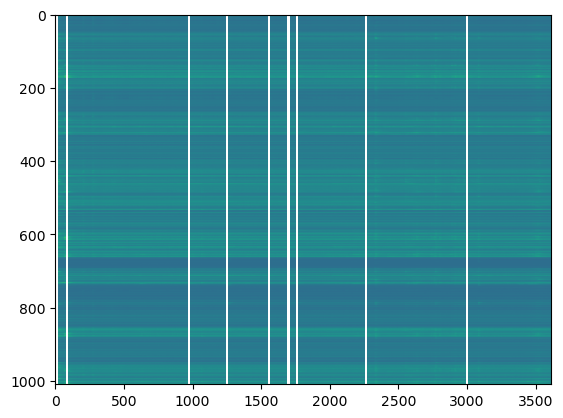

In [4]:
plt.imshow(traces, aspect= 'auto')

#### Data Preprocessing

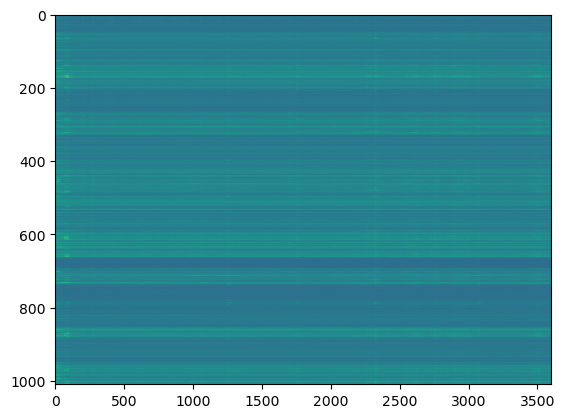

In [5]:
new_traces = replace_nan(traces, bad_frames, delete_frames=True)
plt.imshow(new_traces, aspect= 'auto')

#### Data exploration

After a minimal preprocessing on the data, we can then go ahead and do some data exploration

In [6]:
print(traces.shape)
print('')
print('')
print(new_traces.shape)

(1010, 3613)


(1010, 3601)


Select identified ROIs to be used in the analysis using the `emitter_id` and `receiver_id`

In [7]:
ER_idx = np.r_[emitter_id, receiver_id]

# extract the identified data and output the new data as X
X = new_traces[ER_idx]

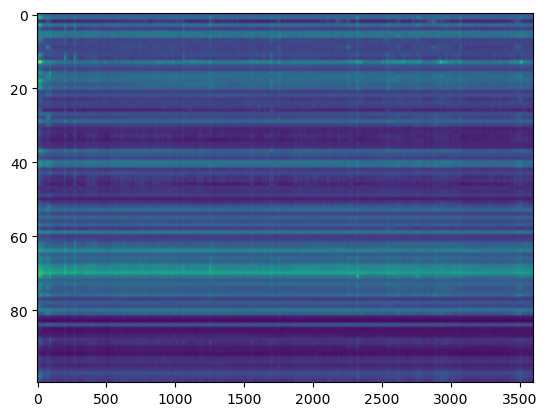

In [8]:
plt.imshow(X, aspect='auto')

### Causal Analysis

We instantiate the class with global variables such as the
   * number of permutation = 1000,
   * number of pasts states = 5,
   * number of lags = 3


In [9]:
gc_star = GcStar(n_perm = 1000, n_pasts = 5, n_lags = 3, temporal = True)

In [10]:
%%time
gc_star.fit(X, verbose = 1)

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete
INFO:src.d_CSL:Step 1/60000 (0.00% complete)
INFO:src.d_CSL:Step 1/60000 (0.00% complete)
INFO:src.d_CSL:Step 2/60000 (0.00% complete)
INFO:src.d_CSL:Step 2/60000 (0.00% complete)
INFO:src.d_CSL:Step 3/60000 (0.01% complete)
INFO:src.d_CSL:Step 3/60000 (0.01% complete)
INFO:src.d_CSL:Step 4/60000 (0.01% complete)
INFO:src.d_CSL:Step 5/60000 (0.01% complete)
INFO:src.d_CSL:Step 4/60000 (0.01% complete)
INFO:src.d_CSL:Step 6/60000 (0.01% complete)
INFO:src.d_CSL:Step 5/60000 (0.01% complete)
INFO:src.d_CSL:Step 7/60000 (0.01% complete)
INFO:src.d_CSL:Step 6/60000 (0.01% complete)
INFO:src.d_CSL:Step 8/60000 (0.01% complete)
INFO:src.d_CSL:Step 7/60000 (0.01% complete)
INFO:src.d_CSL:Step 9/60000 (0.01% complete)
INFO:src.d_CSL:Step 10/60000 (0.02% complete)
INFO:src.d_CSL:Step 8/60000 (0.01% complete)
INFO:src.d_CSL:Step 11

INFO:src.d_CSL:Step 78/60000 (0.13% complete)
INFO:src.d_CSL:Step 99/60000 (0.17% complete)
INFO:src.d_CSL:Step 100/60000 (0.17% complete)
INFO:src.d_CSL:Step 79/60000 (0.13% complete)
INFO:src.d_CSL:Step 101/60000 (0.17% complete)
INFO:src.d_CSL:Step 80/60000 (0.13% complete)
INFO:src.d_CSL:Step 102/60000 (0.17% complete)
INFO:src.d_CSL:Step 81/60000 (0.14% complete)
INFO:src.d_CSL:Step 103/60000 (0.17% complete)
INFO:src.d_CSL:Step 82/60000 (0.14% complete)
INFO:src.d_CSL:Step 104/60000 (0.17% complete)
INFO:src.d_CSL:Step 105/60000 (0.18% complete)
INFO:src.d_CSL:Step 83/60000 (0.14% complete)
INFO:src.d_CSL:Step 106/60000 (0.18% complete)
INFO:src.d_CSL:Step 84/60000 (0.14% complete)
INFO:src.d_CSL:Step 107/60000 (0.18% complete)
INFO:src.d_CSL:Step 85/60000 (0.14% complete)
INFO:src.d_CSL:Step 108/60000 (0.18% complete)
INFO:src.d_CSL:Step 86/60000 (0.14% complete)
INFO:src.d_CSL:Step 109/60000 (0.18% complete)
INFO:src.d_CSL:Step 110/60000 (0.18% complete)
INFO:src.d_CSL:Step 87/

INFO:src.d_CSL:Step 155/60000 (0.26% complete)
INFO:src.d_CSL:Step 197/60000 (0.33% complete)
INFO:src.d_CSL:Step 156/60000 (0.26% complete)
INFO:src.d_CSL:Step 198/60000 (0.33% complete)
INFO:src.d_CSL:Step 199/60000 (0.33% complete)
INFO:src.d_CSL:Step 157/60000 (0.26% complete)
INFO:src.d_CSL:Step 200/60000 (0.33% complete)
INFO:src.d_CSL:Step 158/60000 (0.26% complete)
INFO:src.d_CSL:Step 201/60000 (0.34% complete)
INFO:src.d_CSL:Step 159/60000 (0.27% complete)
INFO:src.d_CSL:Step 202/60000 (0.34% complete)
INFO:src.d_CSL:Step 203/60000 (0.34% complete)
INFO:src.d_CSL:Step 160/60000 (0.27% complete)
INFO:src.d_CSL:Step 204/60000 (0.34% complete)
INFO:src.d_CSL:Step 161/60000 (0.27% complete)
INFO:src.d_CSL:Step 205/60000 (0.34% complete)
INFO:src.d_CSL:Step 162/60000 (0.27% complete)
INFO:src.d_CSL:Step 206/60000 (0.34% complete)
INFO:src.d_CSL:Step 163/60000 (0.27% complete)
INFO:src.d_CSL:Step 207/60000 (0.34% complete)
INFO:src.d_CSL:Step 208/60000 (0.35% complete)
INFO:src.d_CS

INFO:src.d_CSL:Step 294/60000 (0.49% complete)
INFO:src.d_CSL:Step 295/60000 (0.49% complete)
INFO:src.d_CSL:Step 233/60000 (0.39% complete)
INFO:src.d_CSL:Step 296/60000 (0.49% complete)
INFO:src.d_CSL:Step 234/60000 (0.39% complete)
INFO:src.d_CSL:Step 297/60000 (0.50% complete)
INFO:src.d_CSL:Step 235/60000 (0.39% complete)
INFO:src.d_CSL:Step 298/60000 (0.50% complete)
INFO:src.d_CSL:Step 299/60000 (0.50% complete)
INFO:src.d_CSL:Step 236/60000 (0.39% complete)
INFO:src.d_CSL:Step 300/60000 (0.50% complete)
INFO:src.d_CSL:Step 237/60000 (0.40% complete)
INFO:src.d_CSL:Step 301/60000 (0.50% complete)
INFO:src.d_CSL:Step 238/60000 (0.40% complete)
INFO:src.d_CSL:Step 302/60000 (0.50% complete)
INFO:src.d_CSL:Step 239/60000 (0.40% complete)
INFO:src.d_CSL:Step 303/60000 (0.51% complete)
INFO:src.d_CSL:Step 304/60000 (0.51% complete)
INFO:src.d_CSL:Step 240/60000 (0.40% complete)
INFO:src.d_CSL:Step 305/60000 (0.51% complete)
INFO:src.d_CSL:Step 241/60000 (0.40% complete)
INFO:src.d_CS

INFO:src.d_CSL:Step 392/60000 (0.65% complete)
INFO:src.d_CSL:Step 393/60000 (0.66% complete)
INFO:src.d_CSL:Step 310/60000 (0.52% complete)
INFO:src.d_CSL:Step 394/60000 (0.66% complete)
INFO:src.d_CSL:Step 311/60000 (0.52% complete)
INFO:src.d_CSL:Step 395/60000 (0.66% complete)
INFO:src.d_CSL:Step 312/60000 (0.52% complete)
INFO:src.d_CSL:Step 396/60000 (0.66% complete)
INFO:src.d_CSL:Step 313/60000 (0.52% complete)
INFO:src.d_CSL:Step 397/60000 (0.66% complete)
INFO:src.d_CSL:Step 398/60000 (0.66% complete)
INFO:src.d_CSL:Step 314/60000 (0.52% complete)
INFO:src.d_CSL:Step 399/60000 (0.66% complete)
INFO:src.d_CSL:Step 315/60000 (0.53% complete)
INFO:src.d_CSL:Step 400/60000 (0.67% complete)
INFO:src.d_CSL:Step 316/60000 (0.53% complete)
INFO:src.d_CSL:Step 401/60000 (0.67% complete)
INFO:src.d_CSL:Step 317/60000 (0.53% complete)
INFO:src.d_CSL:Step 402/60000 (0.67% complete)
INFO:src.d_CSL:Step 403/60000 (0.67% complete)
INFO:src.d_CSL:Step 318/60000 (0.53% complete)
INFO:src.d_CS

...

INFO:src.d_CSL:Step 59464/60000 (99.11% complete)
INFO:src.d_CSL:Step 59465/60000 (99.11% complete)
INFO:src.d_CSL:Step 59466/60000 (99.11% complete)
INFO:src.d_CSL:Step 59467/60000 (99.11% complete)
INFO:src.d_CSL:Step 59468/60000 (99.11% complete)
INFO:src.d_CSL:Step 59469/60000 (99.11% complete)
INFO:src.d_CSL:Step 59470/60000 (99.12% complete)
INFO:src.d_CSL:Step 59471/60000 (99.12% complete)
INFO:src.d_CSL:Step 59472/60000 (99.12% complete)
INFO:src.d_CSL:Step 59473/60000 (99.12% complete)
INFO:src.d_CSL:Step 59474/60000 (99.12% complete)
INFO:src.d_CSL:Step 59475/60000 (99.12% complete)
INFO:src.d_CSL:Step 59476/60000 (99.13% complete)
INFO:src.d_CSL:Step 59477/60000 (99.13% complete)
INFO:src.d_CSL:Step 59478/60000 (99.13% complete)
INFO:src.d_CSL:Step 59479/60000 (99.13% complete)
INFO:src.d_CSL:Step 59480/60000 (99.13% complete)
INFO:src.d_CSL:Step 59481/60000 (99.13% complete)
INFO:src.d_CSL:Step 59482/60000 (99.14% complete)
INFO:src.d_CSL:Step 59483/60000 (99.14% complete)


INFO:src.d_CSL:Step 59628/60000 (99.38% complete)
INFO:src.d_CSL:Step 59629/60000 (99.38% complete)
INFO:src.d_CSL:Step 59630/60000 (99.38% complete)
INFO:src.d_CSL:Step 59631/60000 (99.39% complete)
INFO:src.d_CSL:Step 59632/60000 (99.39% complete)
INFO:src.d_CSL:Step 59633/60000 (99.39% complete)
INFO:src.d_CSL:Step 59634/60000 (99.39% complete)
INFO:src.d_CSL:Step 59635/60000 (99.39% complete)
INFO:src.d_CSL:Step 59636/60000 (99.39% complete)
INFO:src.d_CSL:Step 59637/60000 (99.39% complete)
INFO:src.d_CSL:Step 59638/60000 (99.40% complete)
INFO:src.d_CSL:Step 59639/60000 (99.40% complete)
INFO:src.d_CSL:Step 59640/60000 (99.40% complete)
INFO:src.d_CSL:Step 59641/60000 (99.40% complete)
INFO:src.d_CSL:Step 59642/60000 (99.40% complete)
INFO:src.d_CSL:Step 59643/60000 (99.41% complete)
INFO:src.d_CSL:Step 59644/60000 (99.41% complete)
INFO:src.d_CSL:Step 59645/60000 (99.41% complete)
INFO:src.d_CSL:Step 59646/60000 (99.41% complete)
INFO:src.d_CSL:Step 59647/60000 (99.41% complete)


INFO:src.d_CSL:Step 59792/60000 (99.65% complete)
INFO:src.d_CSL:Step 59793/60000 (99.66% complete)
INFO:src.d_CSL:Step 59794/60000 (99.66% complete)
INFO:src.d_CSL:Step 59795/60000 (99.66% complete)
INFO:src.d_CSL:Step 59796/60000 (99.66% complete)
INFO:src.d_CSL:Step 59797/60000 (99.66% complete)
INFO:src.d_CSL:Step 59798/60000 (99.66% complete)
INFO:src.d_CSL:Step 59799/60000 (99.67% complete)
INFO:src.d_CSL:Step 59800/60000 (99.67% complete)
INFO:src.d_CSL:Step 59801/60000 (99.67% complete)
INFO:src.d_CSL:Step 59802/60000 (99.67% complete)
INFO:src.d_CSL:Step 59803/60000 (99.67% complete)
INFO:src.d_CSL:Step 59804/60000 (99.67% complete)
INFO:src.d_CSL:Step 59805/60000 (99.67% complete)
INFO:src.d_CSL:Step 59806/60000 (99.68% complete)
INFO:src.d_CSL:Step 59807/60000 (99.68% complete)
INFO:src.d_CSL:Step 59808/60000 (99.68% complete)
INFO:src.d_CSL:Step 59809/60000 (99.68% complete)
INFO:src.d_CSL:Step 59810/60000 (99.68% complete)
INFO:src.d_CSL:Step 59811/60000 (99.69% complete)


INFO:src.d_CSL:Step 59956/60000 (99.93% complete)
INFO:src.d_CSL:Step 59957/60000 (99.93% complete)
INFO:src.d_CSL:Step 59958/60000 (99.93% complete)
INFO:src.d_CSL:Step 59959/60000 (99.93% complete)
INFO:src.d_CSL:Step 59960/60000 (99.93% complete)
INFO:src.d_CSL:Step 59961/60000 (99.94% complete)
INFO:src.d_CSL:Step 59962/60000 (99.94% complete)
INFO:src.d_CSL:Step 59963/60000 (99.94% complete)
INFO:src.d_CSL:Step 59964/60000 (99.94% complete)
INFO:src.d_CSL:Step 59965/60000 (99.94% complete)
INFO:src.d_CSL:Step 59966/60000 (99.94% complete)
INFO:src.d_CSL:Step 59967/60000 (99.94% complete)
INFO:src.d_CSL:Step 59968/60000 (99.95% complete)
INFO:src.d_CSL:Step 59969/60000 (99.95% complete)
INFO:src.d_CSL:Step 59970/60000 (99.95% complete)
INFO:src.d_CSL:Step 59971/60000 (99.95% complete)
INFO:src.d_CSL:Step 59972/60000 (99.95% complete)
INFO:src.d_CSL:Step 59973/60000 (99.95% complete)
INFO:src.d_CSL:Step 59974/60000 (99.96% complete)
INFO:src.d_CSL:Step 59975/60000 (99.96% complete)


CPU times: total: 1d 21h 11min 42s
Wall time: 9h 28min 36s


### Plot extended connectivity and inferred connectivity matrices

<IPython.core.display.Javascript object>


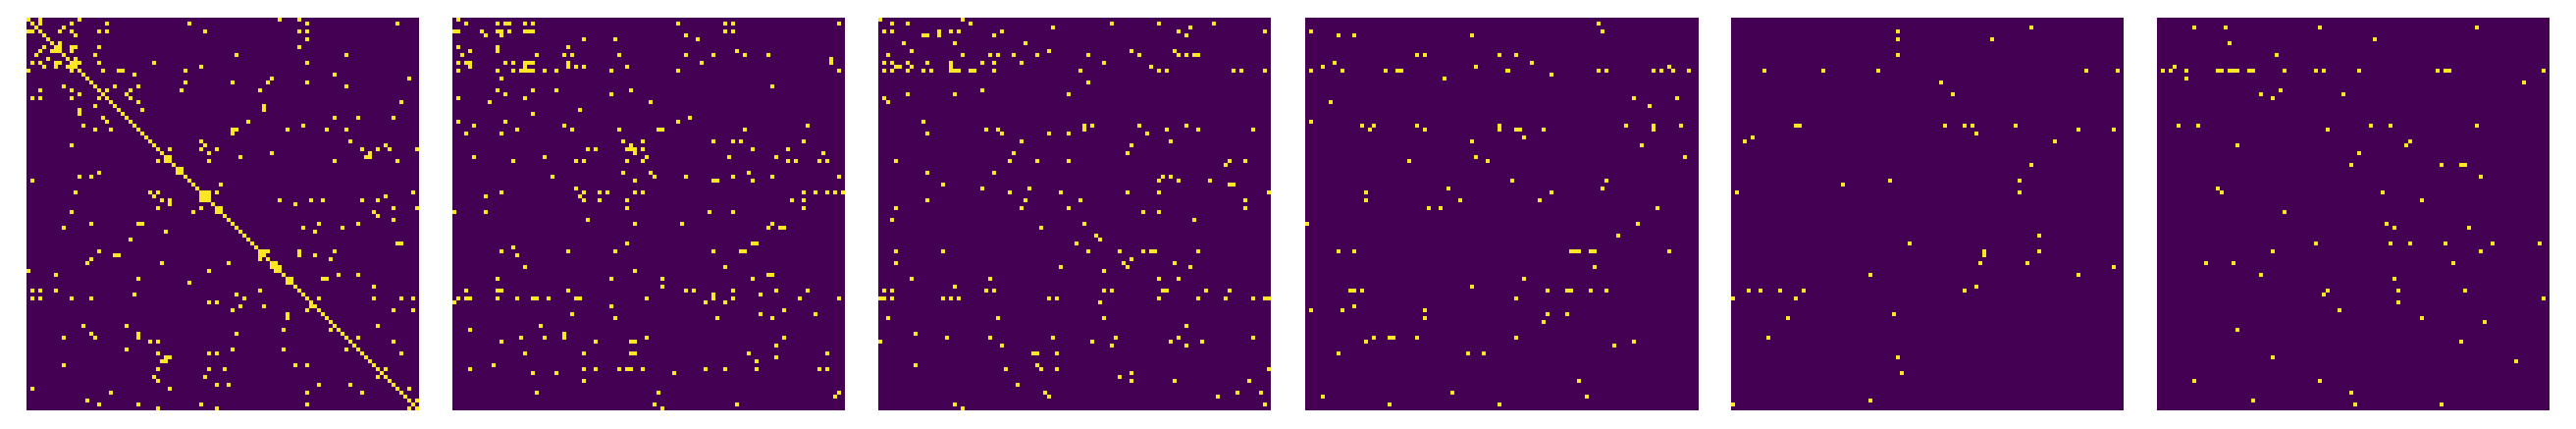

In [15]:
gc_star.plot_extended_connectivity_matrix()

Text(0.5, 1.0, '832 connections')

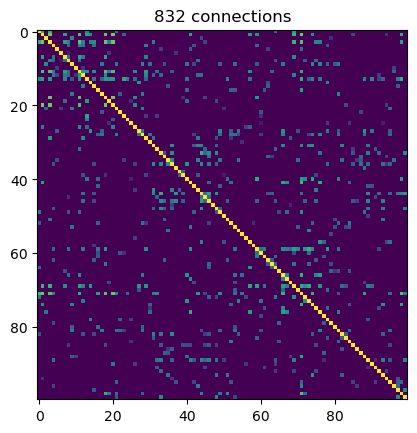

In [11]:
inferred = gc_star.get_connectivity_matrix()
plt.imshow(inferred)
plt.title(f'{np.sum(inferred != 0)} connections')

In [39]:
# np.save('inferred', inferred)
inferred = np.load('inferred.npy')

### Visualisation of results

Instantiate the visualisation class

In [34]:
visualise = Visualize_on_topography(n_perm = 1000, n_pasts = 5, n_lags = 3) 

In [38]:
p = np.transpose(np.where(inferred != 0))
p[0,0]

0

In [40]:
%matplotlib notebook
visualise.plot_conn_mat_on_topography(topography, inferred, roi_idx=ER_idx)

IndexError: index 54 is out of bounds for axis 0 with size 3